In [1]:
# --------------------------------------------------
# GLOBAL RANDOM SEED (TO MAKE RESULTS REPRODUCIBLE)
# --------------------------------------------------

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# -------------------------
# STEP 0: IMPORTS & PATH SETUP
# -------------------------
import pandas as pd
from pathlib import Path

# Base directory = the folder where your notebook is stored
base_dir = Path(".").resolve()
print("Base directory:", base_dir)

# Path to the HUGE Reddit dataset folder (33 CSVs)
huge_dir = base_dir / "Reddit Data huge"

print("Huge dataset folder:", huge_dir)

Base directory: C:\Users\jawli\Downloads\JAWLICHING FYP FOLDER
Huge dataset folder: C:\Users\jawli\Downloads\JAWLICHING FYP FOLDER\Reddit Data huge


In [3]:
# -------------------------
# STEP 1: LOAD HUGE DATASET (Reddit Data huge)
# -------------------------

# Get list of all CSV files in the folder
csv_files = list(huge_dir.glob("*.csv"))
print("Number of CSV files:", len(csv_files))
csv_files[:5]

Number of CSV files: 32


[WindowsPath('C:/Users/jawli/Downloads/JAWLICHING FYP FOLDER/Reddit Data huge/AdviceForTeens_data.csv'),
 WindowsPath('C:/Users/jawli/Downloads/JAWLICHING FYP FOLDER/Reddit Data huge/Anxiety_reddit_data.csv'),
 WindowsPath('C:/Users/jawli/Downloads/JAWLICHING FYP FOLDER/Reddit Data huge/ApplyingToCollege_data.csv'),
 WindowsPath('C:/Users/jawli/Downloads/JAWLICHING FYP FOLDER/Reddit Data huge/astrology_data.csv'),
 WindowsPath('C:/Users/jawli/Downloads/JAWLICHING FYP FOLDER/Reddit Data huge/business_data.csv')]

In [4]:
# STEP 2: PREVIEW FIRST 5 CSV FILES TO CHECK COLUMN STRUCTURE
# This helps check if all files have the same column names and structure

for f in csv_files[:5]:
    print("Previewing:", f.name)        # Show the file name
    temp = pd.read_csv(f, nrows=5)      # Read only the first 5 rows (fast)
    print(temp.columns)                 # Print column names
    print("-" * 60)                     # Separator line for readability

Previewing: AdviceForTeens_data.csv
Index(['Unnamed: 0', 'ID', 'is_Original', 'Flair', 'num_comments', 'Title',
       'Subreddit', 'Body', 'URL', 'Upvotes', 'Comments', 'creation_date'],
      dtype='object')
------------------------------------------------------------
Previewing: Anxiety_reddit_data.csv
Index(['Unnamed: 0', 'ID', 'is_Original', 'Flair', 'num_comments', 'Title',
       'Subreddit', 'Body', 'URL', 'Upvotes', 'Comments', 'creation_date'],
      dtype='object')
------------------------------------------------------------
Previewing: ApplyingToCollege_data.csv
Index(['Unnamed: 0', 'ID', 'is_Original', 'Flair', 'num_comments', 'Title',
       'Subreddit', 'Body', 'URL', 'Upvotes', 'Comments', 'creation_date'],
      dtype='object')
------------------------------------------------------------
Previewing: astrology_data.csv
Index(['Unnamed: 0', 'ID', 'is_Original', 'Flair', 'num_comments', 'Title',
       'Subreddit', 'Body', 'URL', 'Upvotes', 'Comments', 'creation_date'],
 

In [5]:
# STEP 3: LOAD AND COMBINE ALL 32 CSVs FROM REDDIT DATA HUGE

df_list = []

for f in csv_files:
    print("Loading:", f.name)
    df_part = pd.read_csv(f, low_memory=False)

    # Drop Unnamed: 0 if exists
    if 'Unnamed: 0' in df_part.columns:
        df_part = df_part.drop(columns=['Unnamed: 0'])
    
    df_list.append(df_part)

# Combine into one big DataFrame
df_huge = pd.concat(df_list, ignore_index=True)

print("Combined shape:", df_huge.shape)
df_huge.head()

Loading: AdviceForTeens_data.csv
Loading: Anxiety_reddit_data.csv
Loading: ApplyingToCollege_data.csv
Loading: astrology_data.csv
Loading: business_data.csv
Loading: careerguidance_data.csv
Loading: college.csv
Loading: college_data.csv
Loading: Colombia_reddit_data.csv
Loading: computer_science_data.csv
Loading: COVID19_data.csv
Loading: dating_data.csv
Loading: depression_reddit_data.csv
Loading: employment_reddit_data.csv
Loading: engineering_data.csv
Loading: Entrepreneur_data.csv
Loading: feminism_data.csv
Loading: GradSchool_data.csv
Loading: high_school.csv
Loading: kidsrights_data.csv
Loading: merged_reddit_data.csv
Loading: Mexico_spanishlanguage_reddit_data.csv
Loading: NeutralPolitics_data.csv
Loading: povertyfinance_data.csv
Loading: science_data.csv
Loading: student_affairs.csv
Loading: suicidewatch_data.csv
Loading: teenagers.csv
Loading: whatsbotheringyou_reddit_data.csv
Loading: youthandgov_data.csv
Loading: youthknows_data.csv
Loading: youthrights_data.csv
Combined sha

,ID,is_Original,Flair,num_comments,Title,Subreddit,Body,URL,Upvotes,Comments,creation_date,is_original,Text,Sentiment
0,fcpbui,False,NaN,13.0,Can't have sex the same,AdviceForTeens,"I'm in a relationship of 2 years, naturally be...",https://www.reddit.com/r/AdviceForTeens/commen...,24,Have you tried trying your hardest to just con...,2020-03-03 12:39:21,NaN,NaN,NaN
1,fbtk1w,False,NaN,3.0,How to break up with a friend in the most peac...,AdviceForTeens,I’d love for us to slide off of each other but...,https://www.reddit.com/r/AdviceForTeens/commen...,18,there’s really two ways you can do this.\r\nth...,2020-03-01 20:44:48,NaN,NaN,NaN
2,1681jg,False,NaN,4.0,[MODPOST] [META] Lets bring this subreddit bac...,AdviceForTeens,Hey everyone! I'm one of your friendly neighbo...,https://www.reddit.com/r/AdviceForTeens/commen...,21,Me: http://i.imgur.com/QqKyW.jpg\r\n\r\nI also...,2013-01-09 10:23:30,NaN,NaN,NaN
3,fcmxds,False,NaN,0.0,The most important thing when texting a girl i...,AdviceForTeens,Here are some tips on how to text a girl and s...,https://www.reddit.com/r/AdviceForTeens/commen...,18,NaN,2020-03-03 09:33:01,NaN,NaN,NaN
4,f9gz1a,False,NaN,15.0,"My dad found my porn, help",AdviceForTeens,So.. I got a virus onto my laptop so my dad de...,https://www.reddit.com/r/AdviceForTeens/commen...,18,"How old are you? If you’re of reasonable age, ...",2020-02-26 04:51:52,NaN,NaN,NaN


In [6]:
# Check the structure of the combined dataset
# This shows number of rows, columns, and data types
df_huge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37580 entries, 0 to 37579
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             34712 non-null  object 
 1   is_Original    26311 non-null  object 
 2   Flair          19587 non-null  object 
 3   num_comments   29179 non-null  float64
 4   Title          29179 non-null  object 
 5   Subreddit      37580 non-null  object 
 6   Body           16405 non-null  object 
 7   URL            29179 non-null  object 
 8   Upvotes        37580 non-null  int64  
 9   Comments       27163 non-null  object 
 10  creation_date  37580 non-null  object 
 11  is_original    2868 non-null   object 
 12  Text           8400 non-null   object 
 13  Sentiment      8401 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 4.0+ MB


In [7]:
# Check the top 20 most common subreddits in the dataset
# Helps you understand which communities have the most posts
df_huge['Subreddit'].value_counts().head(20)

Subreddit
jobs                 4990
college              2653
highschool           1996
studentaffairs       1972
YouthRights          1868
AdviceForTeens       1636
GradSchool           1538
depression_help      1000
NeutralPolitics      1000
Anxiety              1000
Feminism             1000
Colombia             1000
careerguidance       1000
Entrepreneur          999
mexico                998
whatsbotheringyou     996
ApplyingToCollege     995
engineering           994
dating                993
COVID19               992
Name: count, dtype: int64

In [8]:
# Check the percentage of missing values in each column
# This helps identify which columns need cleaning or can be dropped
df_huge.isna().mean().sort_values(ascending=False)

is_original      0.923683
Text             0.776477
Sentiment        0.776450
Body             0.563465
Flair            0.478792
is_Original      0.299867
Comments         0.277195
num_comments     0.223550
Title            0.223550
URL              0.223550
ID               0.076317
Subreddit        0.000000
Upvotes          0.000000
creation_date    0.000000
dtype: float64

In [9]:
raw_rows = df_huge.shape[0]
raw_rows

37580

In [10]:
# --------------------------------------------------
# STEP 4: CLEAN & FEATURE-ENGINEER THE DATAFRAME 
# --------------------------------------------------

# 1. Start with combined raw dataframe
df = df_huge.copy()

# 2. Standardize column names to lowercase
df.columns = df.columns.str.lower()

# 3. Merge 'text' into 'body' (because both represent post content)
#    - Many CSVs use 'body'
#    - Some CSVs use 'text'
#    - We unify them into ONE final 'body' column
if 'text' in df.columns:
    df['body'] = df['body'].fillna(df['text'])

# 4. Drop columns we do not need anymore
#    - 'text' has been merged into 'body'
#    - 'is_original' duplicates 'is_Original' and is mostly empty
#    - 'sentiment' is mostly missing and unreliable
#    - 'unnamed: 0' is an index column from some CSVs
cols_to_drop = ['text', 'is_original', 'sentiment', 'unnamed: 0']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 5. Drop rows where BOTH title AND body are missing
#    (We keep posts with only body or only title — that is normal Reddit behaviour)
df = df.dropna(subset=['title', 'body'], how='all')

# 6. Replace remaining missing title/body with empty strings
df['title'] = df['title'].fillna("")
df['body'] = df['body'].fillna("")

# 7. Convert creation_date to datetime
df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

# 8. Extract time features
df['post_hour'] = df['creation_date'].dt.hour
df['post_day'] = df['creation_date'].dt.day_name()
df['post_month'] = df['creation_date'].dt.month
df['post_year'] = df['creation_date'].dt.year

# 9. Text length features
df['title_length'] = df['title'].astype(str).str.len()
df['body_length'] = df['body'].astype(str).str.len()

# 10. Preview
print(df.shape)
df.info()
df[['title', 'body']].head()

(37579, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 37579 entries, 0 to 37579
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             34711 non-null  object        
 1   flair          19587 non-null  object        
 2   num_comments   29179 non-null  float64       
 3   title          37579 non-null  object        
 4   subreddit      37579 non-null  object        
 5   body           37579 non-null  object        
 6   url            29179 non-null  object        
 7   upvotes        37579 non-null  int64         
 8   comments       27163 non-null  object        
 9   creation_date  37579 non-null  datetime64[ns]
 10  post_hour      37579 non-null  int32         
 11  post_day       37579 non-null  object        
 12  post_month     37579 non-null  int32         
 13  post_year      37579 non-null  int32         
 14  title_length   37579 non-null  int64         
 15  body_length 

,title,body
0,Can't have sex the same,"I'm in a relationship of 2 years, naturally be..."
1,How to break up with a friend in the most peac...,I’d love for us to slide off of each other but...
2,[MODPOST] [META] Lets bring this subreddit bac...,Hey everyone! I'm one of your friendly neighbo...
3,The most important thing when texting a girl i...,Here are some tips on how to text a girl and s...
4,"My dad found my porn, help",So.. I got a virus onto my laptop so my dad de...


In [11]:
# -------------------------
# STEP 5: CREATE POPULARITY LABEL
# -------------------------

# Compute median upvote value
median_upvotes = df['upvotes'].median()
print("Median upvotes:", median_upvotes)

# Define popularity label: 1 = popular, 0 = not popular
df['popular'] = (df['upvotes'] >= median_upvotes).astype(int)

# Check class balance
print(df['popular'].value_counts())
print(df['popular'].value_counts(normalize=True))

Median upvotes: 130.0
popular
1    18812
0    18767
Name: count, dtype: int64
popular
1    0.500599
0    0.499401
Name: proportion, dtype: float64


In [12]:
# --------------------------------------------------
# STEP 6: BASELINE MODEL — TF-IDF + LOGISTIC REGRESSION 
# --------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# 1) Use cleaned body text as an input feature
X_text = df["body"].fillna("")
y = df["popular"]

# 2) Split into train and test sets
X_train_text, X_test_text, y_train_base, y_test_base = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Convert text to TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# 4) Train logistic regression baseline model
baseline_model = LogisticRegression(max_iter=200)
baseline_model.fit(X_train_tfidf, y_train_base)

# 5) Predict on test set
y_pred_base = baseline_model.predict(X_test_tfidf)

# 6) Evaluate baseline model
acc_base  = accuracy_score(y_test_base, y_pred_base)
prec_base = precision_score(y_test_base, y_pred_base, zero_division=0)
rec_base  = recall_score(y_test_base, y_pred_base, zero_division=0)
f1_base   = f1_score(y_test_base, y_pred_base, zero_division=0)
cm_base   = confusion_matrix(y_test_base, y_pred_base)

print("=== Baseline: TF-IDF + Logistic Regression ===")
print("Accuracy:", acc_base)
print("Precision:", prec_base)
print("Recall:", rec_base)
print("F1:", f1_base)
print("\nClassification Report:\n", classification_report(y_test_base, y_pred_base, zero_division=0))
print("\nConfusion Matrix:\n", cm_base)

# 7) Save results (for final comparison table)
baseline_results = {
    "Model": "TF-IDF + Logistic Regression (Text Baseline)",
    "Accuracy": acc_base,
    "Precision": prec_base,
    "Recall": rec_base,
    "F1": f1_base
}
baseline_results

=== Baseline: TF-IDF + Logistic Regression ===
Accuracy: 0.782064928153273
Precision: 0.73356781710266
Recall: 0.8867924528301887
F1: 0.8029355149181906

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.68      0.76      3753
           1       0.73      0.89      0.80      3763

    accuracy                           0.78      7516
   macro avg       0.79      0.78      0.78      7516
weighted avg       0.79      0.78      0.78      7516


Confusion Matrix:
 [[2541 1212]
 [ 426 3337]]


{'Model': 'TF-IDF + Logistic Regression (Text Baseline)',
 'Accuracy': 0.782064928153273,
 'Precision': 0.73356781710266,
 'Recall': 0.8867924528301887,
 'F1': 0.8029355149181906}

In [13]:
# --------------------------------------------------
# STEP 6A: SAVE BASELINE MODEL RESULTS
# --------------------------------------------------

baseline_results = {
    "Model": "TF-IDF + Logistic Regression (Text Baseline)",
    "Accuracy": acc_base,
    "Precision": prec_base,
    "Recall": rec_base,
    "F1": f1_base
}

baseline_results

{'Model': 'TF-IDF + Logistic Regression (Text Baseline)',
 'Accuracy': 0.782064928153273,
 'Precision': 0.73356781710266,
 'Recall': 0.8867924528301887,
 'F1': 0.8029355149181906}

In [14]:
!pip install seaborn

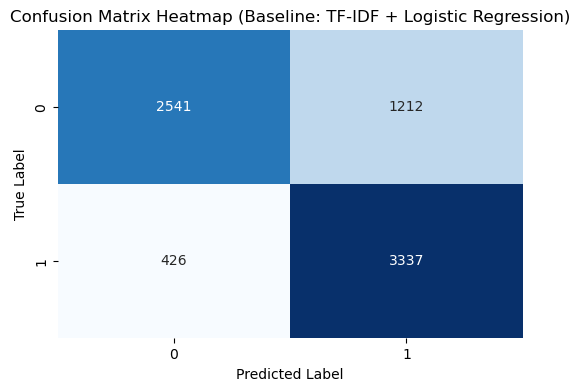

In [15]:
# -------------------------
# CONFUSION MATRIX HEATMAP (BASELINE)
# -------------------------

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_base = confusion_matrix(y_test_base, y_pred_base)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap (Baseline: TF-IDF + Logistic Regression)")
plt.show()

In [16]:
# -------------------------
# TOP PREDICTIVE WORDS (BASELINE)
# -------------------------

import numpy as np

# Get TF-IDF vocabulary
feature_names = vectorizer.get_feature_names_out()

# Logistic Regression coefficients (one per word)
coefficients = baseline_model.coef_[0]

# Top 20 words that predict POPULAR posts (positive coefficients)
top_popular_idx = np.argsort(coefficients)[-20:]
top_popular_words = feature_names[top_popular_idx]

# Top 20 words that predict UNPOPULAR posts (negative coefficients)
top_unpopular_idx = np.argsort(coefficients)[:20]
top_unpopular_words = feature_names[top_unpopular_idx]

print("Words most associated with POPULAR posts:\n")
print(top_popular_words)

print("\nWords most associated with UNPOPULAR posts:\n")
print(top_unpopular_words)

Words most associated with POPULAR posts:

['kill' 'trump' 'coffee' 'people' 'women' 'business' 'dorm' 'dating'
 'roommate' 'update' 'finally' 'proud' 'com' 'essays' 'professors'
 'anxiety' 'www' 'college' 'professor' 'edit']

Words most associated with UNPOPULAR posts:

['youth' 'children' 'student' 'hi' 'affairs' 'child' 'program' 'teen'
 'kids' 'depression' 'position' 'young' 'training' 'thesis' 'job' 'phd'
 'know' 'rights' 'friend' 'ap']


In [17]:
# --------------------------------------------------
# STEP 7: PREPARE FINAL FEATURES (X) AND LABEL (y)
# --------------------------------------------------

# 1) Combine title + body into one text field
df["text_all"] = (df["title"].fillna("") + " " + df["body"].fillna("")).str.strip()

# 2) Clean / fill important fields used by models
df["num_comments"] = df["num_comments"].fillna(0).astype(int)
df["flair"] = df["flair"].fillna("none")
df["subreddit"] = df["subreddit"].fillna("unknown")
df["post_day"] = df["post_day"].fillna("unknown")

# 3) Select final input features for models
feature_cols = [
    "text_all",        # text
    "subreddit",       # categorical
    "post_day",        # categorical
    "flair",           # categorical
    "post_hour",       # numeric
    "post_month",      # numeric
    "num_comments",    # numeric
    "title_length",    # numeric
    "body_length"      # numeric
]

X = df[feature_cols]
y = df["popular"]

# 4) Quick sanity checks
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())
print("\nExample row:\n", X.head(1))

X shape: (37579, 9)
y distribution:
 popular
1    18812
0    18767
Name: count, dtype: int64

Example row:
                                             text_all       subreddit post_day  \
0  Can't have sex the same I'm in a relationship ...  AdviceForTeens  Tuesday   

  flair  post_hour  post_month  num_comments  title_length  body_length  
0  none         12           3            13            23          601  


In [18]:
# --------------------------------------------------
# STEP 8: ADVANCED MODEL 1 (RANDOM FOREST - METADATA + TEMPORAL)
# --------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1) Select features for Random Forest (exclude text)
rf_feature_cols = [
    "subreddit",       # categorical
    "post_day",        # categorical
    "flair",           # categorical
    "post_hour",       # numeric
    "post_month",      # numeric
    "num_comments",    # numeric
    "title_length",    # numeric
    "body_length"      # numeric
]

X_rf = df[rf_feature_cols]
y = df["popular"]

# 2) Define categorical and numeric columns
cat_cols = ["subreddit", "post_day", "flair"]
num_cols = ["post_hour", "post_month", "num_comments", "title_length", "body_length"]

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Preprocessing: One-Hot Encode categorical, pass numeric through
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# 5) Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_model = Pipeline(steps=[("preprocess", preprocess), ("model", rf)])

# 6) Train model
rf_model.fit(X_train, y_train)

# 7) Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)
cm_rf   = confusion_matrix(y_test, y_pred_rf)

print("=== Random Forest (Metadata + Temporal) ===")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1:", f1_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))
print("\nConfusion Matrix:\n", cm_rf)

=== Random Forest (Metadata + Temporal) ===
Accuracy: 0.9501064395955295
Precision: 0.9541554959785523
Recall: 0.9457879351581185
F1: 0.9499532897370879

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      3753
           1       0.95      0.95      0.95      3763

    accuracy                           0.95      7516
   macro avg       0.95      0.95      0.95      7516
weighted avg       0.95      0.95      0.95      7516


Confusion Matrix:
 [[3582  171]
 [ 204 3559]]


In [19]:
# --------------------------------------------------
# STEP 8A: SAVE RANDOM FOREST RESULTS
# --------------------------------------------------

rf_results = {
    "Model": "Random Forest (Metadata + Temporal)",
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1": f1_rf
}

rf_results

{'Model': 'Random Forest (Metadata + Temporal)',
 'Accuracy': 0.9501064395955295,
 'Precision': 0.9541554959785523,
 'Recall': 0.9457879351581185,
 'F1': 0.9499532897370879}

In [20]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [21]:
# --------------------------------------------------
# STEP 9: ADVANCED MODEL 2 (XGBOOST - METADATA + TEMPORAL)
# --------------------------------------------------

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Reuse same feature setup as Random Forest

X_xgb = df[rf_feature_cols]
y = df["popular"]

# Train/test split (same settings for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y, test_size=0.2, random_state=42, stratify=y
)

# Same preprocessing (OneHot for categorical)
xgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Metrics (use unique names)
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb  = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb   = f1_score(y_test, y_pred_xgb, zero_division=0)
cm_xgb   = confusion_matrix(y_test, y_pred_xgb)

print("=== XGBoost (Metadata + Temporal) ===")
print("Accuracy:", acc_xgb)
print("Precision:", prec_xgb)
print("Recall:", rec_xgb)
print("F1:", f1_xgb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))
print("\nConfusion Matrix:\n", cm_xgb)

=== XGBoost (Metadata + Temporal) ===
Accuracy: 0.950904736562001
Precision: 0.958400864397623
Recall: 0.9428647355833112
F1: 0.950569323509712

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      3753
           1       0.96      0.94      0.95      3763

    accuracy                           0.95      7516
   macro avg       0.95      0.95      0.95      7516
weighted avg       0.95      0.95      0.95      7516


Confusion Matrix:
 [[3599  154]
 [ 215 3548]]


In [22]:
# --------------------------------------------------
# STEP 9A: SAVE XGBOOST RESULTS
# --------------------------------------------------

xgb_results = {
    "Model": "XGBoost (Metadata + Temporal)",
    "Accuracy": acc_xgb,
    "Precision": prec_xgb,
    "Recall": rec_xgb,
    "F1": f1_xgb
}

xgb_results

{'Model': 'XGBoost (Metadata + Temporal)',
 'Accuracy': 0.950904736562001,
 'Precision': 0.958400864397623,
 'Recall': 0.9428647355833112,
 'F1': 0.950569323509712}

In [23]:
# --------------------------------------------------
# STEP 10: ADVANCED MODEL 3 (NEURAL NETWORK - METADATA + TEMPORAL)
# --------------------------------------------------

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

# Use same data split as before
X_nn = df[rf_feature_cols]
y = df["popular"]

X_train, X_test, y_train, y_test = train_test_split(
    X_nn, y, test_size=0.2, random_state=42, stratify=y
)

# One-hot encode categorical features (reuse preprocess)
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

# Scale features (important for neural networks)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Build neural network
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping 
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss_nn, acc_nn = model.evaluate(X_test_scaled, y_test, verbose=0)

# Predict 
y_prob_nn = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

prec_nn = precision_score(y_test, y_pred_nn, zero_division=0)
rec_nn  = recall_score(y_test, y_pred_nn, zero_division=0)
f1_nn   = f1_score(y_test, y_pred_nn, zero_division=0)
cm_nn   = confusion_matrix(y_test, y_pred_nn)

print("=== Neural Network (Metadata + Temporal) ===")
print("Accuracy:", acc_nn)
print("Precision:", prec_nn)
print("Recall:", rec_nn)
print("F1:", f1_nn)
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn, zero_division=0))
print("\nConfusion Matrix:\n", cm_nn)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8491 - loss: 0.3877 - val_accuracy: 0.9451 - val_loss: 0.1665
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.1765 - val_accuracy: 0.9493 - val_loss: 0.1475
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9431 - loss: 0.1598 - val_accuracy: 0.9501 - val_loss: 0.1427
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9437 - loss: 0.1484 - val_accuracy: 0.9503 - val_loss: 0.1402
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9446 - loss: 0.1502 - val_accuracy: 0.9498 - val_loss: 0.1383
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9445 - loss: 0.1448 - val_accuracy: 0.9506 - val_loss: 0.1375
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9462 - loss: 0.1419 - val_accuracy: 0.9511 - val_loss: 0.1362
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9464 - loss: 0.1393 - val_accuracy: 0.9501 - val_loss:

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          24,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,301 (309.77 KB)

 Trainable params: 26,433 (103.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,868 (206.52 KB)

In [25]:
# --------------------------------------------------
# STEP 10A: SAVE NEURAL NETWORK RESULTS
# --------------------------------------------------

nn_results = {
    "Model": "Neural Network (Metadata + Temporal)",
    "Accuracy": acc_nn,
    "Precision": prec_nn,
    "Recall": rec_nn,
    "F1": f1_nn
}

nn_results

{'Model': 'Neural Network (Metadata + Temporal)',
 'Accuracy': 0.9509047269821167,
 'Precision': 0.9672356828193832,
 'Recall': 0.9335636460271061,
 'F1': 0.9501014198782961}

In [26]:
# --------------------------------------------------
# STEP 11: FINAL MODEL COMPARISON TABLE
# --------------------------------------------------

import pandas as pd

all_results = [
    baseline_results,
    rf_results,
    xgb_results,
    nn_results
]

comparison_df = pd.DataFrame(all_results)

# Sort by F1 (best model on top)
comparison_df = comparison_df.sort_values(by="F1", ascending=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1
2,XGBoost (Metadata + Temporal),0.950905,0.958401,0.942865,0.950569
3,Neural Network (Metadata + Temporal),0.950905,0.967236,0.933564,0.950101
1,Random Forest (Metadata + Temporal),0.950106,0.954155,0.945788,0.949953
0,TF-IDF + Logistic Regression (Text Baseline),0.782065,0.733568,0.886792,0.802936


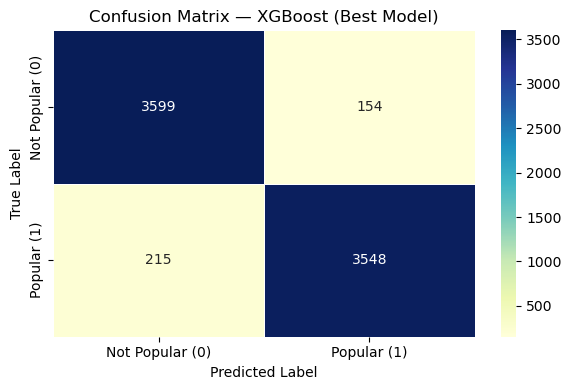

In [27]:
# --------------------------------------------------
# VIS 1: CONFUSION MATRIX (BEST MODEL: XGBOOST)
# --------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Recreate split (same seed)
X_xgb = df[rf_feature_cols]
y = df["popular"]

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb, y, test_size=0.2, random_state=42, stratify=y
)

# Predict
y_pred_best = xgb_model.predict(X_test)

cm_best = confusion_matrix(y_test, y_pred_best)

labels = ["Not Popular (0)", "Popular (1)"]

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="YlGnBu",      
    cbar=True,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)

plt.title("Confusion Matrix — XGBoost (Best Model)", fontsize=12)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

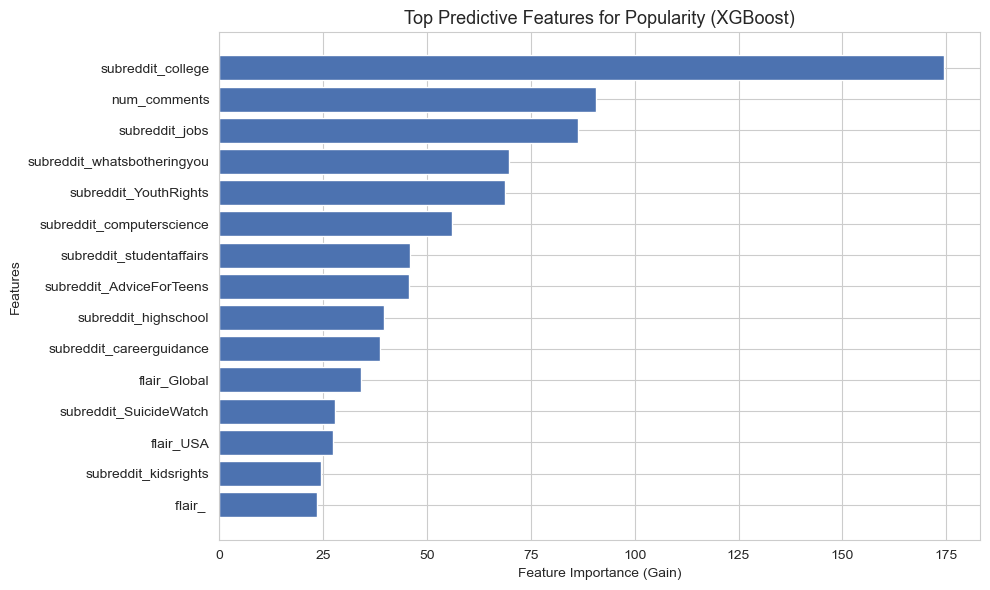

In [28]:
# --------------------------------------------------
# VIS 2: FEATURE IMPORTANCE WITH READABLE NAMES (XGBOOST)
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Get one-hot feature names from preprocess
ohe = xgb_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([cat_feature_names, np.array(num_cols)])

# Get importance from XGBoost booster
booster = xgb_model.named_steps["model"].get_booster()
score_dict = booster.get_score(importance_type="gain")

# Map f0,f1,... -> readable names
rows = []
for k, v in score_dict.items():
    idx = int(k[1:])
    if idx < len(all_feature_names):
        rows.append((all_feature_names[idx], v))

imp_df = (
    pd.DataFrame(rows, columns=["Feature", "Importance"])
    .sort_values("Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    imp_df["Feature"][::-1],
    imp_df["Importance"][::-1],
    color="#4C72B0"   # same soft blue as other charts
)

plt.title("Top Predictive Features for Popularity (XGBoost)", fontsize=13)
plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

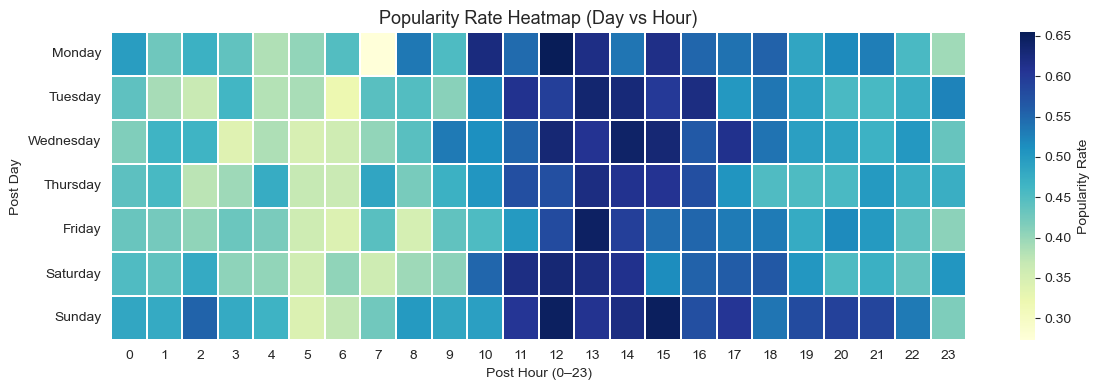

In [29]:
# --------------------------------------------------
# VIS 3: HEATMAP (DAY x HOUR) OF POPULARITY RATE
# --------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

pivot = df.pivot_table(
    values="popular",
    index="post_day",
    columns="post_hour",
    aggfunc="mean"
).reindex(day_order)

plt.figure(figsize=(12,4))

sns.heatmap(
    pivot,
    cmap="YlGnBu",        # nicer colour palette
    cbar_kws={"label": "Popularity Rate"},
    linewidths=0.3
)

plt.xlabel("Post Hour (0–23)")
plt.ylabel("Post Day")
plt.title("Popularity Rate Heatmap (Day vs Hour)", fontsize=13)

plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_model,
    X_xgb,
    y,
    cv=skf,
    scoring='f1'
)

print("CV F1:", cv_scores)
print("Mean:", np.mean(cv_scores))
print("Std:", np.std(cv_scores))

CV F1: [0.95450875 0.95071841 0.95390782 0.95364416 0.95427115]
Mean: 0.9534100574589642
Std: 0.0013781249576486142


In [31]:
import joblib

joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']